In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings('ignore')

print("Successfully")

Successfully


In [3]:
import pandas as pd

df = pd.read_csv("C:/Users/Mehedi Hasan/OneDrive/Desktop/1MLProject/data/spam_ham_dataset.csv")

print(df.shape)
print(df.head())

(5171, 4)
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  


In [4]:
# Drop unnamed column
df = df.drop(columns=['Unnamed: 0'])

# Remove duplicate emails
df = df.drop_duplicates(subset=['text'])

print(df.shape)
print(df['label'].value_counts())

(4993, 3)
label
ham     3531
spam    1462
Name: count, dtype: int64


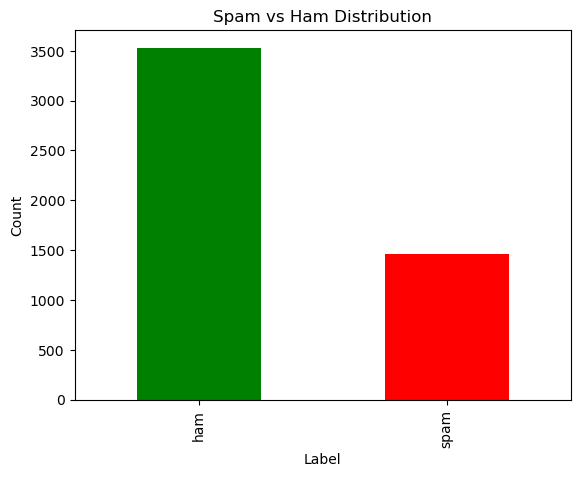

        count         mean          std   min     25%    50%     75%      max
label                                                                        
ham    3531.0   994.939394  1402.785831  18.0  241.00  538.0  1253.5  32258.0
spam   1462.0  1249.326265  1840.112883  11.0  304.25  589.0  1305.0  22073.0


In [5]:
import matplotlib.pyplot as plt

# Class distribution
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Check email length
df['length'] = df['text'].apply(len)
print(df.groupby('label')['length'].describe())

In [6]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print(df[['text', 'clean_text']].head())

                                                text  \
0  Subject: enron methanol ; meter # : 988291\r\n...   
1  Subject: hpl nom for january 9 , 2001\r\n( see...   
2  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3  Subject: photoshop , windows , office . cheap ...   
4  Subject: re : indian springs\r\nthis deal is t...   

                                          clean_text  
0  subject enron methanol meter this is a follow ...  
1  subject hpl nom for january see attached file ...  
2  subject neon retreat ho ho ho we re around to ...  
3  subject photoshop windows office cheap main tr...  
4  subject re indian springs this deal is to book...  


In [7]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 3994
Test size: 999


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print(X_train_vectorized.shape)
print(X_test_vectorized.shape)

(3994, 5000)
(999, 5000)


In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vectorized, y_train)

print("Naive Bayes model trained")

Naive Bayes model trained


In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_vectorized, y_train)

print("KNN model trained")

KNN model trained


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
nb_pred = nb_model.predict(X_test_vectorized)
knn_pred = knn_model.predict(X_test_vectorized)

# Naive Bayes Results
print("="*40)
print("NAIVE BAYES RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(f"Precision: {precision_score(y_test, nb_pred):.4f}")
print(f"Recall: {recall_score(y_test, nb_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, nb_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

print("\n"+"="*40)
print("KNN RESULTS")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, knn_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_pred):.4f}")
print(f"Recall: {recall_score(y_test, knn_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, knn_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

NAIVE BAYES RESULTS
Accuracy: 0.9620
Precision: 0.9225
Recall: 0.9363
F1 Score: 0.9294

Confusion Matrix:
[[711  21]
 [ 17 250]]

KNN RESULTS
Accuracy: 0.9670
Precision: 0.9606
Recall: 0.9139
F1 Score: 0.9367

Confusion Matrix:
[[722  10]
 [ 23 244]]


In [12]:
import joblib

# Save Naive Bayes model
joblib.dump(nb_model, 'nb_spam_model.pkl')

# Save KNN model
joblib.dump(knn_model, 'knn_spam_model.pkl')

# Save vectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')

print("✅ All models saved successfully")

✅ All models saved successfully
